In [2]:
# carregar o data set

import pandas as pd

df = pd.read_csv("/content/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# visão geral da base

print("Shape:", df.shape)
print("\nColunas:")
print(df.columns)

print("\nTipos de dados:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

Shape: (50000, 2)

Colunas:
Index(['review', 'sentiment'], dtype='object')

Tipos de dados:
review       object
sentiment    object
dtype: object

Valores nulos:
review       0
sentiment    0
dtype: int64


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


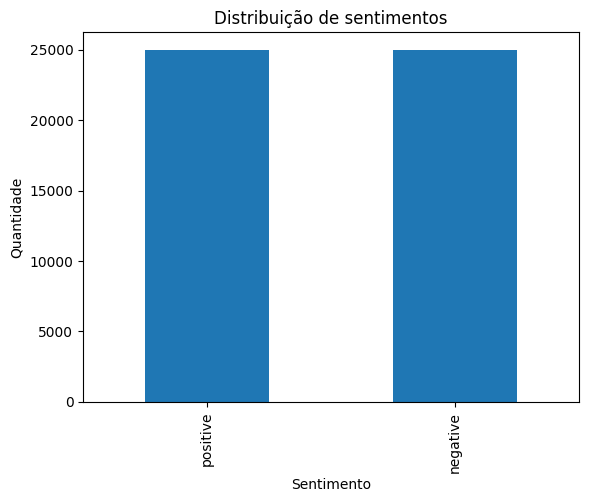

In [4]:
# distribuição de sentimentos

import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

plt.figure()
sentiment_counts.plot(kind="bar")
plt.title("Distribuição de sentimentos")
plt.xlabel("Sentimento")
plt.ylabel("Quantidade")
plt.show()

In [5]:
# limpeza básica do texto

import re

def clean_text(text):
    text = str(text)
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.lower().strip()

df["review_clean"] = df["review"].apply(clean_text)

count    50000.000000
mean       235.562460
std        174.335414
min          6.000000
25%        129.000000
50%        177.000000
75%        286.000000
max       2505.000000
Name: review_length, dtype: float64


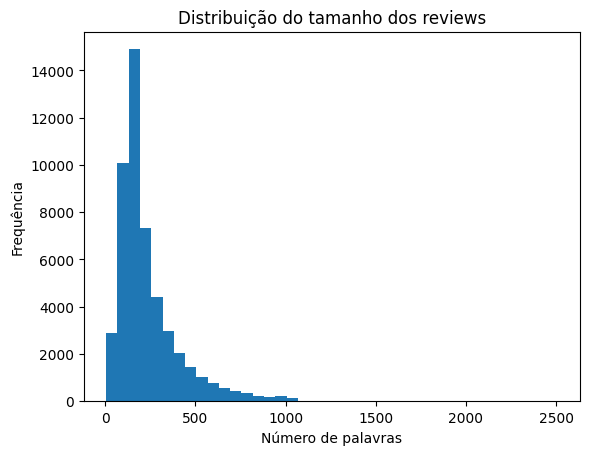

In [6]:
# tamanho dos reviews

df["review_length"] = df["review_clean"].apply(lambda x: len(x.split()))

print(df["review_length"].describe())

plt.figure()
plt.hist(df["review_length"], bins=40)
plt.title("Distribuição do tamanho dos reviews")
plt.xlabel("Número de palavras")
plt.ylabel("Frequência")
plt.show()

      word  count
0      not  60750
1     have  55204
2      one  53603
3      all  46950
4      who  42234
5     like  40172
6    there  37525
7      has  33038
8     what  32240
9     some  31135
10    good  29753
11    when  28062
12    more  28017
13    time  25110
14    even  24871
15   which  23402
16    only  23241
17   story  23121
18  really  23095
19     see  23029


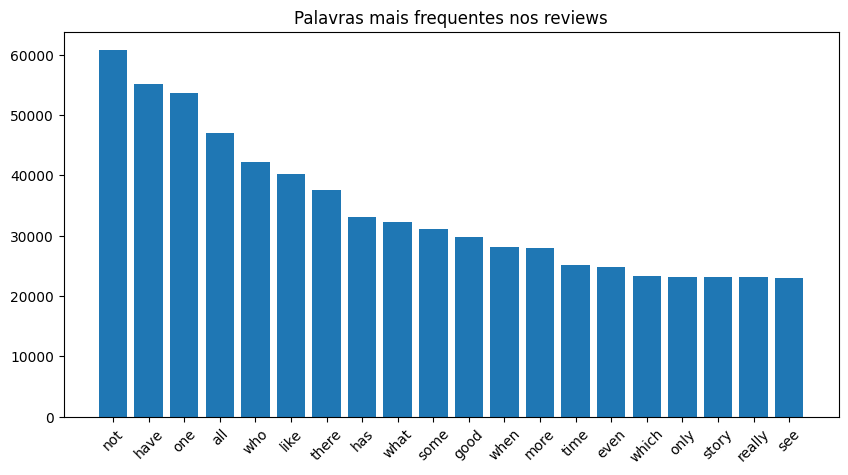

In [7]:
# palavras mais frequentes

from collections import Counter

# stopwords simples
stopwords = {
    "the","a","an","and","or","is","it","this","that","to","of","for","in","on","with","as",
    "was","were","are","be","by","at","from","i","you","he","she","they","we","my","our","your",
    "his","her","their","me","him","them","but","if","then","so","than","too","very","can","could",
    "would","should","will","just","about","into","out","up","down","over","under","again","once",
    "movie","film"
}

all_words = " ".join(df["review_clean"]).split()

filtered_words = [w for w in all_words if w not in stopwords and len(w) > 2]

word_freq = Counter(filtered_words).most_common(20)

freq_df = pd.DataFrame(word_freq, columns=["word", "count"])
print(freq_df)

plt.figure(figsize=(10,5))
plt.bar(freq_df["word"], freq_df["count"])
plt.xticks(rotation=45)
plt.title("Palavras mais frequentes nos reviews")
plt.show()

In [8]:
# 3 - criação dos embeddings das avaliações

# filtrar reviews positivos

df_pos = df[df["sentiment"] == "positive"].copy()

print("Quantidade de reviews positivos:", df_pos.shape[0])
df_pos.head()



Quantidade de reviews positivos: 25000


,review,sentiment,review_clean,review_length
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,314
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,160
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,168
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is a...,228
5,"Probably my all-time favorite movie, a story o...",positive,probably my all time favorite movie a story of...,125


In [9]:
# usar amostra de 3K

df_pos_sample = df_pos.sample(n=3000, random_state=42)

In [10]:
# instala modelo de embeddings

!pip install sentence-transformers

In [11]:
# gera embeddings dos reviews

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

reviews_list = df_pos_sample["review_clean"].tolist()

review_embeddings = model.encode(reviews_list, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [12]:
# cria perfil médio do usuário

import numpy as np

user_profile = np.mean(review_embeddings, axis=0).reshape(1, -1)

print("Dimensão do perfil:", user_profile.shape)

Dimensão do perfil: (1, 384)


In [14]:
# carregar arquivos movies

movies_df = pd.read_csv("/content/movies.csv")
tags_df = pd.read_csv("/content/tags.csv")

print("Movies:", movies_df.shape)
print("Tags:", tags_df.shape)

movies_df.head()

Movies: (9742, 3)
Tags: (3683, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [15]:
# visão geral

print("\nColunas movies:")
print(movies_df.columns)

print("\nColunas tags:")
print(tags_df.columns)

print("\nValores nulos movies:")
print(movies_df.isnull().sum())

print("\nValores nulos tags:")
print(tags_df.isnull().sum())


Colunas movies:
Index(['movieId', 'title', 'genres'], dtype='object')

Colunas tags:
Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')

Valores nulos movies:
movieId    0
title      0
genres     0
dtype: int64

Valores nulos tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


In [16]:
# quantidade de filmes

total_movies = movies_df["movieId"].nunique()
print("Total de filmes:", total_movies)

Total de filmes: 9742


In [17]:
# distribuição de gêneros

from collections import Counter

genre_counter = Counter()

for genres in movies_df["genres"]:
    for g in str(genres).split("|"):
        if g != "(no genres listed)":
            genre_counter[g] += 1

genre_df = pd.DataFrame(genre_counter.items(), columns=["genre", "count"])
genre_df = genre_df.sort_values(by="count", ascending=False)

print(genre_df.head(10))

        genre  count
6       Drama   4361
3      Comedy   3756
9    Thriller   1894
7      Action   1828
5     Romance   1596
0   Adventure   1263
8       Crime   1199
12     Sci-Fi    980
10     Horror    978
4     Fantasy    779


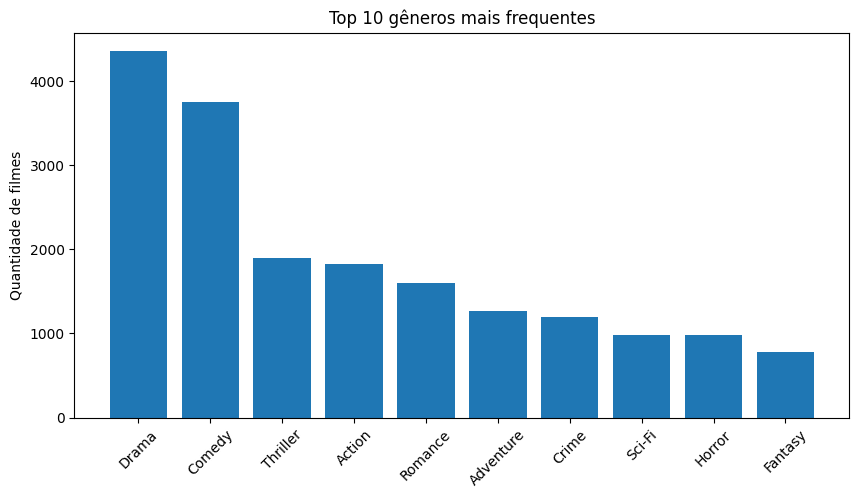

In [18]:
# gráfico de gêneros

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(genre_df.head(10)["genre"], genre_df.head(10)["count"])
plt.xticks(rotation=45)
plt.title("Top 10 gêneros mais frequentes")
plt.ylabel("Quantidade de filmes")
plt.show()

In [19]:
# quantidade de tags por filme

tags_per_movie = tags_df.groupby("movieId").size().reset_index(name="tag_count")

print(tags_per_movie["tag_count"].describe())

count    1572.000000
mean        2.342875
std         5.562342
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       181.000000
Name: tag_count, dtype: float64


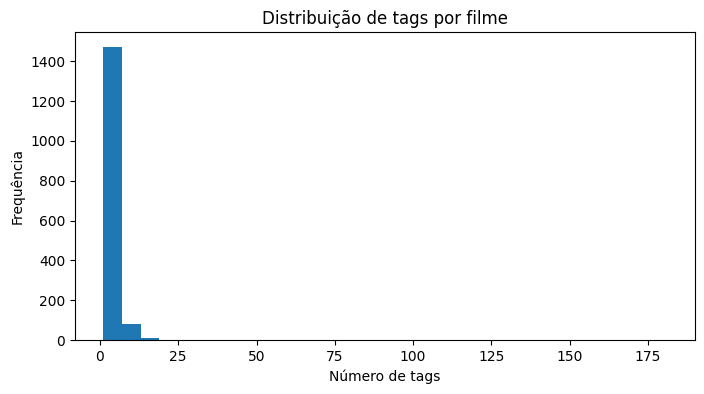

In [20]:
# distribuição de tags

plt.figure(figsize=(8,4))
plt.hist(tags_per_movie["tag_count"], bins=30)
plt.title("Distribuição de tags por filme")
plt.xlabel("Número de tags")
plt.ylabel("Frequência")
plt.show()

In [21]:
# exemplos de tags

tags_df.head(10)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
5,2,89774,Tom Hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,Leonardo DiCaprio,1445715051
8,2,106782,Martin Scorsese,1445715056
9,7,48516,way too long,1169687325


In [22]:
# preparação dos dados: movie + tags

# agrupar tags por filme

tags_agg = (
    tags_df.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(sorted(set(map(str, x.dropna())))))
    .reset_index()
)

tags_agg.head()

,movieId,tag
0,1,fun pixar
1,2,Robin Williams fantasy game magic board game
2,3,moldy old
3,5,pregnancy remake
4,7,remake


In [23]:
# juntar com movie

movies_enriched = movies_df.merge(tags_agg, on="movieId", how="left")

movies_enriched.head()

,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,fun pixar
1,2,Jumanji (1995),Adventure|Children|Fantasy,Robin Williams fantasy game magic board game
2,3,Grumpier Old Men (1995),Comedy|Romance,moldy old
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,NaN
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake


In [24]:
#tratar valores vazios

movies_enriched["tag"] = movies_enriched["tag"].fillna("")

In [25]:
# criar o campo movie_text

def build_movie_text(row):
    title = str(row["title"])
    genres = str(row["genres"]).replace("|", " ")
    tags = str(row["tag"])

    return f"title: {title}. genres: {genres}. tags: {tags}"

movies_enriched["movie_text"] = movies_enriched.apply(build_movie_text, axis=1)

In [26]:
# verificar o resultado

movies_enriched[["title", "movie_text"]].head(5)

,title,movie_text
0,Toy Story (1995),title: Toy Story (1995). genres: Adventure Ani...
1,Jumanji (1995),title: Jumanji (1995). genres: Adventure Child...
2,Grumpier Old Men (1995),title: Grumpier Old Men (1995). genres: Comedy...
3,Waiting to Exhale (1995),title: Waiting to Exhale (1995). genres: Comed...
4,Father of the Bride Part II (1995),title: Father of the Bride Part II (1995). gen...


In [27]:
# gerar os embeddings dos filmes

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
# gerar embeddings

movie_texts = movies_enriched["movie_text"].tolist()

movie_embeddings = model.encode(
    movie_texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/305 [00:00<?, ?it/s]

In [29]:
# verificação

print("Shape dos embeddings dos filmes:", movie_embeddings.shape)

Shape dos embeddings dos filmes: (9742, 384)


In [30]:
# cálculo de similaridades

from sklearn.metrics.pairwise import cosine_similarity
similarities = cosine_similarity(user_profile, movie_embeddings)
similarities = similarities.flatten()

In [31]:
# adicionar ao dataframe e ordenar (ranking)

movies_enriched["similarity"] = similarities

recommendations = movies_enriched.sort_values(
    by="similarity",
    ascending=False
)



In [32]:
# top 10 - recomendação

top_10 = recommendations.head(10)

top_10[["title", "genres", "similarity"]]

,title,genres,similarity
8304,Inside Llewyn Davis (2013),Drama,0.552631
6648,There Will Be Blood (2007),Drama|Western,0.523057
4976,Chaplin (1992),Drama,0.519623
2558,Do the Right Thing (1989),Drama,0.509708
6840,"Onion Movie, The (2008)",Comedy,0.503544
7362,Best Worst Movie (2009),Documentary,0.501583
5372,Ray (2004),Drama,0.501295
4268,"Talk of the Town, The (1942)",Comedy|Romance|Thriller,0.497521
8535,Ward 13 (2003),Action|Animation|Comedy|Horror,0.496003
8088,Movie 43 (2013),Comedy,0.495978


In [33]:
# avaliação do modelo

avg_similarity = top_10["similarity"].mean()

print("Similaridade média (Top-10):", avg_similarity)

Similaridade média (Top-10): 0.5100943


In [34]:
# Precision@K

expected_genres = ["Drama", "Thriller"]

def precision_at_k(df, expected_genres):
    relevant = 0

    for _, row in df.iterrows():
        movie_genres = row["genres"].split("|")

        if any(g in expected_genres for g in movie_genres):
            relevant += 1

    return relevant / len(df)



In [35]:
# cálculo

p_at_10 = precision_at_k(top_10, expected_genres)

print("Precision@10:", p_at_10)

Precision@10: 0.6


In [36]:
# Etapa 3 - carregar ratings

ratings_df = pd.read_csv("/content/ratings.csv")

print("Ratings:", ratings_df.shape)
ratings_df.head()

Ratings: (100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [37]:
# Calcular média e quantidade de avaliações por filme

ratings_stats = (
    ratings_df.groupby("movieId")["rating"]
    .agg(["mean", "count"])
    .reset_index()
)

ratings_stats.columns = ["movieId", "rating_mean", "rating_count"]

ratings_stats.head()

,movieId,rating_mean,rating_count
0,1,3.920930,215
1,2,3.431818,110
2,3,3.259615,52
3,4,2.357143,7
4,5,3.071429,49


In [38]:
# Integrar ratings ao dataframe de filmes

movies_adjusted = movies_enriched.merge(
    ratings_stats,
    on="movieId",
    how="left"
)

movies_adjusted[["title", "genres", "similarity", "rating_mean", "rating_count"]].head()

,title,genres,similarity,rating_mean,rating_count
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0.339141,3.920930,215.0
1,Jumanji (1995),Adventure|Children|Fantasy,0.256441,3.431818,110.0
2,Grumpier Old Men (1995),Comedy|Romance,0.356772,3.259615,52.0
3,Waiting to Exhale (1995),Comedy|Drama|Romance,0.344383,2.357143,7.0
4,Father of the Bride Part II (1995),Comedy,0.354593,3.071429,49.0


In [39]:
# Testar filmes sem ratings

movies_adjusted["rating_mean"] = movies_adjusted["rating_mean"].fillna(0)
movies_adjusted["rating_count"] = movies_adjusted["rating_count"].fillna(0)

In [40]:
# Aplicar filtro de qualidade

filtered_movies = movies_adjusted[
    (movies_adjusted["rating_mean"] >= 3.5) &
    (movies_adjusted["rating_count"] >= 20)
].copy()

print("Filmes antes do filtro:", movies_adjusted.shape[0])
print("Filmes após o filtro:", filtered_movies.shape[0])

Filmes antes do filtro: 9742
Filmes após o filtro: 730


In [41]:
# Gerar novo top-10 ajustado

top_10_adjusted = (
    filtered_movies
    .sort_values(by="similarity", ascending=False)
    .head(10)
)

top_10_adjusted[["title", "genres", "similarity", "rating_mean", "rating_count"]]

,title,genres,similarity,rating_mean,rating_count
6648,There Will Be Blood (2007),Drama|Western,0.523057,4.142857,28.0
2558,Do the Right Thing (1989),Drama,0.509708,4.037037,27.0
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.493961,4.197068,307.0
190,Clerks (1994),Comedy,0.486057,3.855769,104.0
8252,Gravity (2013),Action|Sci-Fi|IMAX,0.482811,3.578125,32.0
9463,Logan (2017),Action|Sci-Fi,0.481039,4.280000,25.0
6887,Role Models (2008),Comedy,0.480186,3.625000,20.0
4117,Adaptation (2002),Comedy|Drama|Romance,0.476941,3.945652,46.0
7372,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,0.476294,4.066434,143.0
4909,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi,0.476169,4.160305,131.0


In [42]:
# Recalcular a similaridade média

avg_similarity_baseline = top_10["similarity"].mean()
avg_similarity_adjusted = top_10_adjusted["similarity"].mean()

print("Similaridade média baseline:", avg_similarity_baseline)
print("Similaridade média ajustada:", avg_similarity_adjusted)

Similaridade média baseline: 0.5100943
Similaridade média ajustada: 0.48862213


In [43]:
# Recalcular precision

precision_10_baseline = precision_at_k(top_10, expected_genres)
precision_10_adjusted = precision_at_k(top_10_adjusted, expected_genres)

print("Precision@10 baseline:", precision_10_baseline)
print("Precision@10 ajustado:", precision_10_adjusted)

Precision@10 baseline: 0.6
Precision@10 ajustado: 0.6


In [44]:
# Tabela comparativa antes e depois dos ajustes da etapa 3

comparison = pd.DataFrame({
    "Modelo": ["Etapa 2 - Baseline", "Etapa 3 - Ajustado"],
    "Precision@10": [precision_10_baseline, precision_10_adjusted],
    "Similaridade Média Top-10": [avg_similarity_baseline, avg_similarity_adjusted],
    "Filtro aplicado": ["Não", "rating_mean >= 3.5 e rating_count >= 20"]
})

comparison

,Modelo,Precision@10,Similaridade Média Top-10,Filtro aplicado
0,Etapa 2 - Baseline,0.6,0.510094,Não
1,Etapa 3 - Ajustado,0.6,0.488622,rating_mean >= 3.5 e rating_count >= 20
